# Projekt 4

## Filip Nocoń
---

### Inicjalizacja potrzebnych bibliotek

In [1]:
# Tutaj należy zaimport pandas as pdimportować potrzebne biblioteki.:
import pandas as pd
import matplotlib.pyplot as plt
import statistics

from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import f_oneway
import numpy as np
%matplotlib inline

----
### 1. Wczytanie plików z danymi 

In [2]:
df = pd.read_csv("anova_1.csv", sep=';')

lek_a = df['Substancja A']
lek_b = df['Substancja B']
lek_c = df['Substancja C']

---
### 2. Ocena homogeniczności oraz normalności rozkładu na podstawie wykresu pudełkowego 

średnia dla A: 133.26666666666668
mediana dla A: 133.0
średnia dla B: 139.03333333333333
mediana dla B: 139.0
średnia dla C: 137
mediana dla C: 137.0


/tmp/ipykernel_20716/2549898733.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


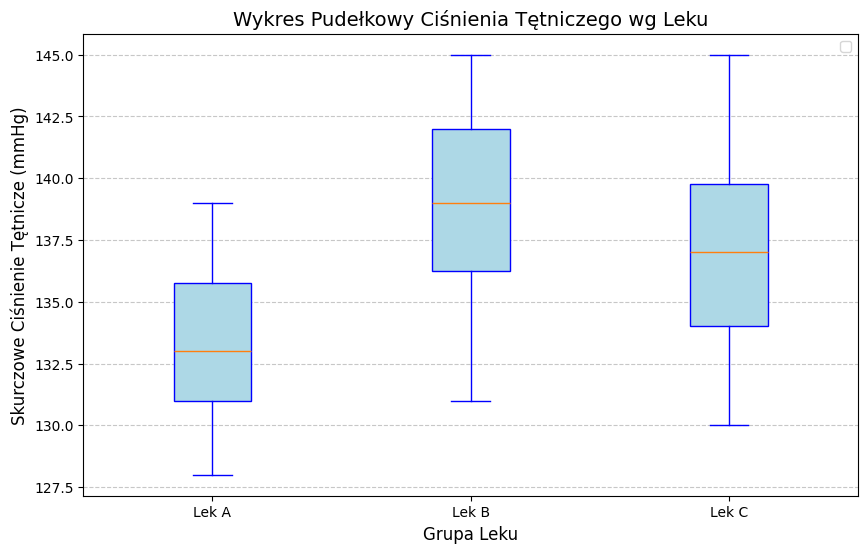

In [3]:
data = [lek_a, lek_b, lek_c]
labels = ['Lek A', 'Lek B', 'Lek C']
print(f"średnia dla A: {statistics.mean(lek_a)}")
print(f"mediana dla A: {statistics.median(lek_a)}")
print(f"średnia dla B: {statistics.mean(lek_b)}")
print(f"mediana dla B: {statistics.median(lek_b)}")
print(f"średnia dla C: {statistics.mean(lek_c)}")
print(f"mediana dla C: {statistics.median(lek_c)}")
plt.figure(figsize=(10, 6))
bp = plt.boxplot(data, patch_artist=True, tick_labels =labels,
                 boxprops=dict(facecolor='lightblue', color='blue'),
                 whiskerprops=dict(color='blue'),
                 capprops=dict(color='blue'))

plt.title('Wykres Pudełkowy Ciśnienia Tętniczego wg Leku', fontsize=14)
plt.ylabel('Skurczowe Ciśnienie Tętnicze (mmHg)', fontsize=12)
plt.xlabel('Grupa Leku', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Wnioski:

Raczej jest homogeniczna, ponieważ wszystkie "wąsy" na siebię nachodzą, dla wszystkich grup rozmiar "pudełek" jest podobny.
Raczej jest z rozkładu normalnego, ponieważ jest symetria mediany, symetria wąsów.

Lek A, na pierwszy rzut oka wygląda jakby działał oraz zniżał ciśnienie najlepiej.

---
### 3. Ocena homogeniczności oraz normalności rozkładu na podstawie testów statystycznych 

In [4]:
#shaprio wilka H_0: rozkład jest normalny

print("Test shapiro-wilka")
print(f"Dla Leku A: {shapiro(lek_a)}")
print(f"Dla Leku B: {shapiro(lek_b)}")
print(f"Dla Leku C: {shapiro(lek_c)}")

#Lavena H_0: Jest homogeniczna
print(f"Test lavena: {levene(lek_a,lek_b,lek_c)}")


Test shapiro-wilka
Dla Leku A: ShapiroResult(statistic=np.float64(0.9743413959794691), pvalue=np.float64(0.663333229227226))
Dla Leku B: ShapiroResult(statistic=np.float64(0.9614867134407615), pvalue=np.float64(0.33791083603648286))
Dla Leku C: ShapiroResult(statistic=np.float64(0.9830791043139832), pvalue=np.float64(0.900153724794721))
Test lavena: LeveneResult(statistic=np.float64(1.739232257407596), pvalue=np.float64(0.18170645077474307))


#### Wnioski:
shapiro-wilka:
    Dla każdej grupy p.value > 0.05, nie ma podstaw do odrzucenia H_0.

Lavena:
    p.value > 0.05, nie ma podstaw do odrzucenia H_0

---
### 4. Wyznaczenie wartości statystyki $F$ i weryfikacja $H_0$

In [5]:
M_a = statistics.mean(lek_a)
M_b = statistics.mean(lek_b)
M_c = statistics.mean(lek_c)
M_global = (M_a * 30 + M_b * 30 + M_c * 30) / 90

print(f"Średnia Lek A: {M_a}")
print(f"Średnia Lek B: {M_b}")
print(f"Średnia Lek C: {M_c}")
print(f"Średnia Globalna: {M_global}")

df_red =  90 - 1
df_full = 90 - 3 # liczebność całości - ilość grup

CW_red = (
    np.sum((lek_a - M_global)**2) +  
    np.sum((lek_b - M_global)**2) +  
    np.sum((lek_c - M_global)**2)    
)
print(f"CW_red: {CW_red}")

CW_full = (
    np.sum((lek_a - M_a)**2) +  
    np.sum((lek_b - M_b)**2) +  
    np.sum((lek_c - M_c)**2)    
)
print(f"CW_full: {CW_full}")
#H_0: lek nie ma wpływu na poziom ciśnienia we krwii.
F = ((CW_red_total - CW_full) / (df_red - df_full))/(CW_full/df_full)
print(f"F wynosi: {F}, a dla F2,87 = 3.10")

Średnia Lek A: 133.26666666666668
Średnia Lek B: 139.03333333333333
Średnia Lek C: 137
Średnia Globalna: 136.43333333333334
CW_red: 1620.1000000000004
CW_full: 1106.8333333333335
F wynosi: 20.172052401746733, a dla F2,87 = 3.10


#### Wnioski:

F wyszyło mi większe od wartości w tabeli więc odrzucamy H_0. Czyli lek ma wpływ na poziom ciśnienia.


---
### 5. Jednoczynnkowa analiza wariancji z wykorzystaniem biblioteki scipy

In [6]:
#H_0 są sobie równe

print(f"ANOVA: {f_oneway(lek_a,lek_b,lek_c,equal_var=True)}")

ANOVA: F_onewayResult(statistic=np.float64(20.172052401746733), pvalue=np.float64(6.346112123576863e-08))


#### Wnioski:
p.value < 0.05, odrzucamy H_0, czyli istnieje statystycznie istotna różnica pomiędzy przynajmniej 2 grupami. Rodzaj leku ma znaczenie na spadek ciśnienia.

In [7]:
# Eksportowanie bieżacego notatnika do pdf.

%run ../data/notebook_export
export_notebook_to_pdf("Projekt4_Nocoń_Filip.ipynb")

Export 'Projekt4_Nocoń_Filip.ipynb': OK.


<Figure size 640x480 with 0 Axes>

**PDF wygenerowano:** Wednesday, 03 December 2025 14:09:33